In [1]:
import os
import numpy as np
import matplotlib.image
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from scipy import ndimage
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib.patches import Circle
from scipy.ndimage import center_of_mass
import cv2

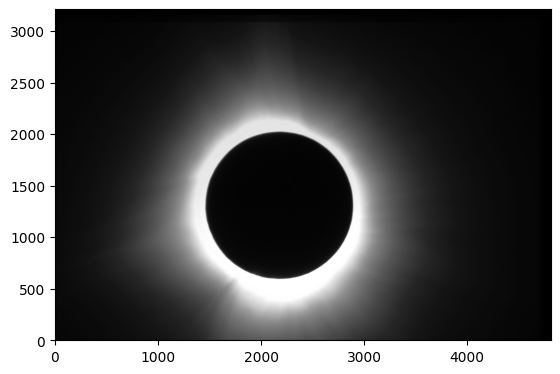

In [12]:
#SOLAR_ECLIPSE_IMAGE = '_DSF3921.tiff'
import cv2



#Manual input
SOLAR_ECLIPSE_IMAGE ='/Volumes/Seagate Por/EdEon/Observatories/R_1yVFawatWSRzbIR/R_1yVFawatWSRzbIR_hdr_eclipse_log_scaled.png'

#'/Volumes/Seagate Por/EdEon/Observatories/R_3Bx2CUNjLFgm5Fk/R_3Bx2CUNjLFgm5Fk_hdr_eclipse_log_scaled.png'
# '/Volumes/Seagate Por/EdEon/Observatories/R_3hMaRJbigfcYCCS/R_3hMaRJbigfcYCCS_hdr_eclipse_log_scaled.png'
#'/Users/jesuslongares/Desktop/FatFile/R_5Ys7VVhYIjOGiZ3/FitsNullPNG/2024-04-08_15-12-19__26c_1.png'
#SOLAR_ECLIPSE_IMAGE = '/Desktop/FatFile/R_5Ys7VVhYIjOGiZ3FitsNullPNG/2024-04-08_15-12-17__26c_1.png'


im_rgba = np.flipud(matplotlib.image.imread(SOLAR_ECLIPSE_IMAGE))
im_rgb = im_rgba[:, :, :3]
im = rgb2gray(im_rgb)



plt.imshow(im, origin="lower", cmap="gray")
plt.show()

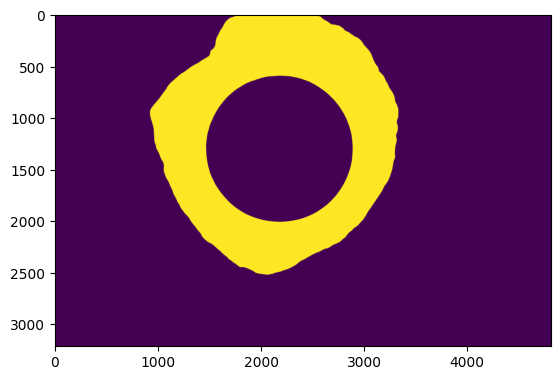

im range: 0.08322274684906006 0.8690804243087769
blur mean: 0.2234581708908081
mask true %: 18.462295641137917 %


In [13]:
blur_im = ndimage.gaussian_filter(im, 4)
mask = blur_im > blur_im.mean() *1.5
plt.imshow(mask)
plt.show()
print("im range:", float(im.min()), float(im.max()))
print("blur mean:", float(blur_im.mean()))
print("mask true %:", 100*np.mean(mask), "%")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from scipy import ndimage
from skimage.transform import hough_circle, hough_circle_peaks, rotate
from skimage.color import rgb2gray

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import get_sun
from sunpy.coordinates.sun import P

from datetime import datetime
from zoneinfo import ZoneInfo


In [15]:
def detect_disc_center_and_radius_from_sobel(im, mask, blur_im ):

#code from the sobel code is adapted into this
    label_im, nb_label = ndimage.label(mask)
    objects = ndimage.find_objects(label_im == 1)
    print(objects)

    if not objects:
        raise RuntimeError("ROI found from mask")
    slice_y, slice_x = ndimage.find_objects(label_im == 1)[0]
    roi = blur_im[slice_y, slice_x]
    sx = ndimage.sobel(roi, axis=1, mode="constant")
    sy = ndimage.sobel(roi, axis=0, mode="constant")
    sob = np.hypot(sx, sy)
    #radii search range
    hough_radii = np.arange(float(np.floor(np.mean(sob.shape)) / 3.6), float(np.ceil(np.mean(sob.shape)) / 1.5), 1.5)
    print(hough_radii)
    hough_res = hough_circle(sob > (sob.mean() * 3), hough_radii)

    # Select the most prominent circle
    accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)

    if(len(cx) == 0): 
        raise RuntimeError(" No circle found; adjust threshold/radii")

    #ROI -> full image coordinates
    cx0, cy0, r0 = float(cx[0]), float(cy[0]), float(radii[0])
    cx_full = slice_x.start + cx0
    cy_full = slice_y.start + cy0
    return cx_full, cy_full, r0
    
    
    
    

In [16]:
#Rotation angle from CSV file
import pandas as pd
from astropy.time import Time
from astropy import units as u
from astropy.coordinates import get_sun, EarthLocation
from sunpy.coordinates.sun import P


In [17]:
def parallactic_angle( lat_deg, lon_deg, obstime, ra, dec):

    lst = obstime.sidereal_time('apparent', longitude=lon_deg*u.deg)
    H = (lst - ra).wrap_at(360*u.deg).to(u.rad).value
    phi = np.deg2rad(lat_deg)
    delta = dec.to(u.rad).value
    # Parallactic angle formula
    chi = np.arctan2(np.sin(H), np.tan(phi)*np.cos(delta) - np.sin(delta)*np.cos(H))
    return chi
    

In [18]:
def rotation_to_solar_north(lat_deg, lon_deg, timestr_utc, camera_mode="level", camera_roll_deg=0.0):
    t = Time(timestr_utc, scale='utc')
    sun = get_sun(t)
    ra, dec = sun.ra, sun.dec
    q  = parallactic_angle(lat_deg, lon_deg, t, ra, dec)     # radians
    P0 = P(t).to(u.rad).value                                # radians
    roll = np.deg2rad(camera_roll_deg)
    if camera_mode == "level":          # camera 'up' = local vertical (tripod/handheld)
        theta = -(P0 + q - roll)
    elif camera_mode == "celestial_up": # camera 'up' = celestial north (well-aligned EQ mount)
        theta = -(P0 - roll)
    else:
        raise ValueError("camera_mode must be 'level' or 'celestial_up'")
    return np.rad2deg(theta)   

In [19]:
from skimage.transform import rotate

def rotate_about_center(image, angle_deg, center_xy, resize=False, mode='edge', preserve_range=True):
    cx, cy = center_xy
    return rotate(image, angle=angle_deg, center=(cy, cx),
                  resize=False, mode='edge', preserve_range=True)


In [20]:
def crop_square_around_center(image, center_xy, half_size):
    cx, cy = map(int, np.round(center_xy))
    H, W = image.shape[:2]
    y0, y1 = max(0, cy - half_size), min(H, cy + half_size)
    x0, x1 = max(0, cx - half_size), min(W, cx + half_size)
    return image[y0:y1, x0:x1]

2024-04-08T19:36:37Z
[(slice(0, 2522, None), slice(920, 3325, None))]
[ 684.16666667  685.66666667  687.16666667  688.66666667  690.16666667
  691.66666667  693.16666667  694.66666667  696.16666667  697.66666667
  699.16666667  700.66666667  702.16666667  703.66666667  705.16666667
  706.66666667  708.16666667  709.66666667  711.16666667  712.66666667
  714.16666667  715.66666667  717.16666667  718.66666667  720.16666667
  721.66666667  723.16666667  724.66666667  726.16666667  727.66666667
  729.16666667  730.66666667  732.16666667  733.66666667  735.16666667
  736.66666667  738.16666667  739.66666667  741.16666667  742.66666667
  744.16666667  745.66666667  747.16666667  748.66666667  750.16666667
  751.66666667  753.16666667  754.66666667  756.16666667  757.66666667
  759.16666667  760.66666667  762.16666667  763.66666667  765.16666667
  766.66666667  768.16666667  769.66666667  771.16666667  772.66666667
  774.16666667  775.66666667  777.16666667  778.66666667  780.16666667
  781.6

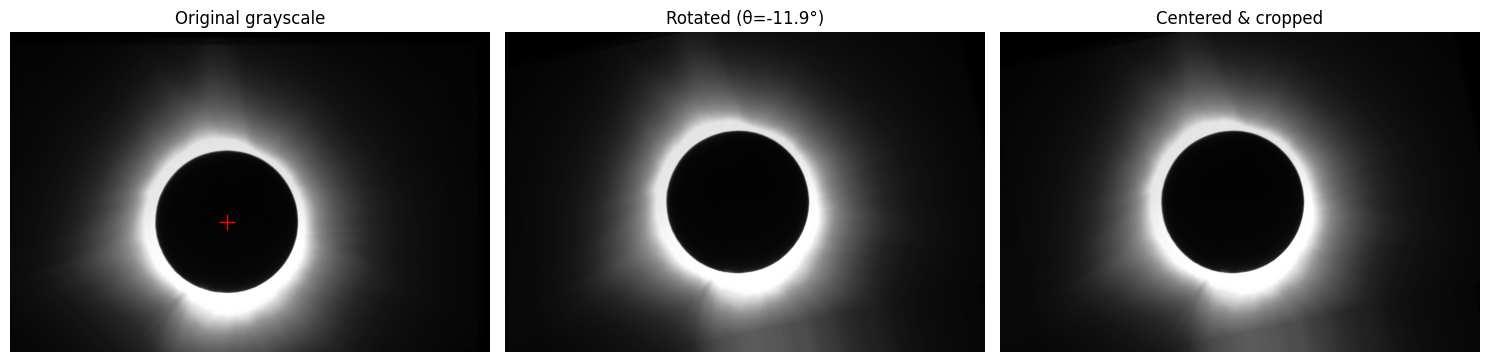

In [22]:
from datetime import datetime
from zoneinfo import ZoneInfo


lat_deg  = 46.68014         # geographic latitude (+N)
lon_deg  = -64.71644       # geographic longitude (+E; West is negative)
#2024:04:08 16:36:37
local_dt = datetime(2024, 4, 8, 16, 36, 37, tzinfo=ZoneInfo("America/Moncton"))
timestamp_utc = local_dt.astimezone(ZoneInfo("UTC")).strftime("%Y-%m-%dT%H:%M:%SZ")
print(timestamp_utc)

cx_full, cy_full, r0 = detect_disc_center_and_radius_from_sobel(
    im, mask, blur_im)


theta_deg = rotation_to_solar_north(
    lat_deg, lon_deg, timestamp_utc,
    camera_mode="level", camera_roll_deg=0.0
)
print(f"Rotation angle (solar north up): {theta_deg:.2f}°")

theta_used = theta_deg;
im_rot = rotate_about_center(im, theta_used, (cx_full, cy_full), resize=True, mode='edge', preserve_range=True)#changed the x and y placement and fixed

half_size = int(round(4.0 * r0)) # change here for how much you want to crop
im_centered = crop_square_around_center(im_rot, (cx_full, cy_full), half_size)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(im, cmap='gray', origin='lower')
ax[0].set_title("Original grayscale")
ax[0].plot(cx_full, cy_full, 'r+', markersize=12)  # mark detected center

ax[1].imshow(im_rot, cmap='gray', origin='lower')
ax[1].set_title(f"Rotated (θ={theta_used:.1f}°)")

ax[2].imshow(im_centered, cmap='gray', origin='lower')
ax[2].set_title("Centered & cropped")
path = '/Volumes/Seagate Por/EdEon/Observatories'
observatory = 'R_1yVFawatWSRzbIR'
# '/Volumes/Seagate Por/EdEon/Observatories/R_2eJ8rlmbu9gZfGx_hdr_eclipse_log_scaled.png'
# png_output_path = f'/Volumes/Seagate Por/EdEon/Observatories/R_1Jbdw0E8TUxdKW_hdr_cropped_rotated.png' # change name {Observatory}_aligned_stacked.png
png_output_path = f'{path}/{observatory}/{observatory}_hdr_cropped_rotated.png' # change name {Observatory}_aligned_stacked.png


plt.imsave(png_output_path, im_centered, cmap="gray", origin="lower")


for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()



[(slice(1248, 1949, None), slice(729, 1482, None))]
[201.94444444 203.44444444 204.94444444 206.44444444 207.94444444
 209.44444444 210.94444444 212.44444444 213.94444444 215.44444444
 216.94444444 218.44444444 219.94444444 221.44444444 222.94444444
 224.44444444 225.94444444 227.44444444 228.94444444 230.44444444
 231.94444444 233.44444444 234.94444444 236.44444444 237.94444444
 239.44444444 240.94444444 242.44444444 243.94444444 245.44444444
 246.94444444 248.44444444 249.94444444 251.44444444 252.94444444
 254.44444444 255.94444444 257.44444444 258.94444444 260.44444444
 261.94444444 263.44444444 264.94444444 266.44444444 267.94444444
 269.44444444 270.94444444 272.44444444 273.94444444 275.44444444
 276.94444444 278.44444444 279.94444444 281.44444444 282.94444444
 284.44444444 285.94444444 287.44444444 288.94444444 290.44444444
 291.94444444 293.44444444 294.94444444 296.44444444 297.94444444
 299.44444444 300.94444444 302.44444444 303.94444444 305.44444444
 306.94444444 308.444444

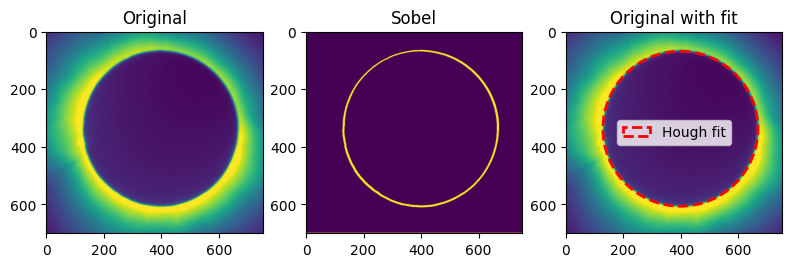

In [8]:
from scipy.ndimage import binary_opening, binary_closing, binary_dilation

mask_clean = binary_closing(binary_opening(mask))
mask_clean = binary_dilation(mask_clean, iterations=4)
label_im, nb_labels = ndimage.label(mask_clean)
objects = ndimage.find_objects(label_im == 1)
print(objects)

slice_y, slice_x = ndimage.find_objects(label_im == 1)[0]
roi = blur_im[slice_y, slice_x]
sx = ndimage.sobel(roi, axis=1, mode="constant")
sy = ndimage.sobel(roi, axis=0, mode="constant")
sob = np.hypot(sx, sy)

#radii search range
hough_radii = np.arange(float(np.floor(np.mean(sob.shape)) / 3.6), float(np.ceil(np.mean(sob.shape)) / 1.5), 1.5)
print(hough_radii)
hough_res = hough_circle(sob > (sob.mean() * 3), hough_radii)

# Select the most prominent circle
accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)



fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(9.5, 6))
ax[0].imshow(im[slice_y, slice_x]) 
ax[0].set_title("Original")
ax[1].imshow(sob > (sob.mean() * 5))
ax[1].set_title("Sobel")
circ = Circle(
    [cx, cy], radius=radii, facecolor="none", edgecolor="red", linewidth=2, linestyle="dashed", label="Hough fit"
)
ax[2].imshow(im[slice_y, slice_x] )

ax[2].add_patch(circ)
ax[2].set_title("Original with fit")
plt.legend()
plt.show()

In [64]:
from scipy.ndimage import gaussian_filter
from skimage import exposure
from scipy.ndimage import sobel

blurred = gaussian_filter(im[slice_y, slice_x], sigma=1)
sobel_radial = sobel(blurred, axis=0)
mask = sobel_radial > 35

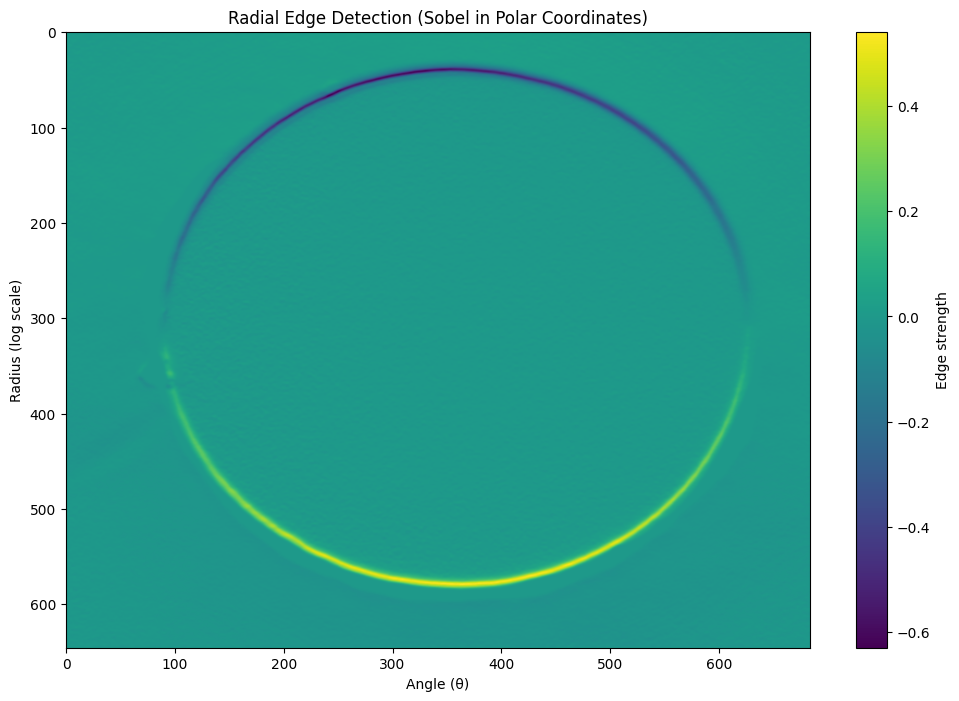

In [68]:
plt.figure(figsize=(12, 8))
plt.imshow(sobel_radial, cmap='viridis', aspect='auto')
plt.title("Radial Edge Detection (Sobel in Polar Coordinates)")
plt.xlabel("Angle (θ)")
plt.ylabel("Radius (log scale)")
plt.colorbar(label="Edge strength")
plt.show()

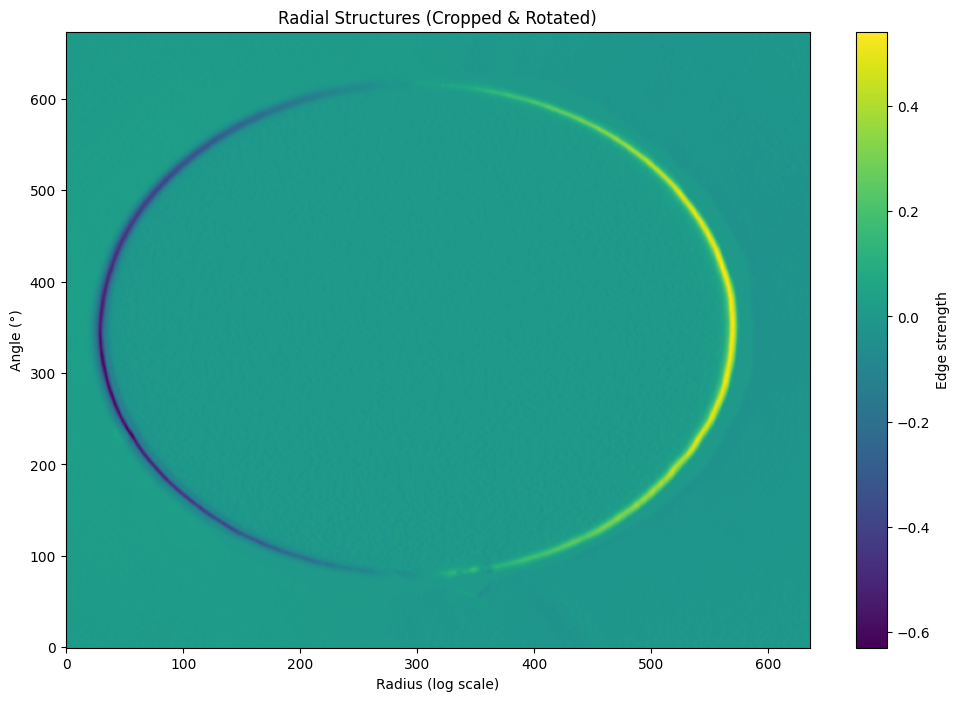

In [67]:
cropped = sobel_radial[10:,10:] 
plt.figure(figsize=(12, 8))
plt.imshow(cropped.T, cmap='viridis', origin='lower', aspect='auto')
plt.title("Radial Structures (Cropped & Rotated)")
plt.xlabel("Radius (log scale)")
plt.ylabel("Angle (°)")
plt.colorbar(label="Edge strength")
plt.show()

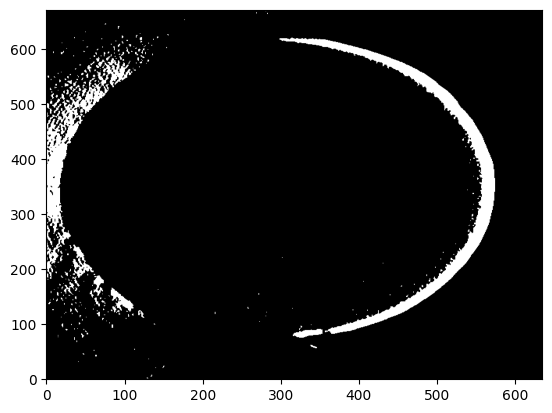

In [42]:
mask = cropped.T > 0.0243
plt.imshow(mask, cmap='gray', origin='lower', aspect='auto')

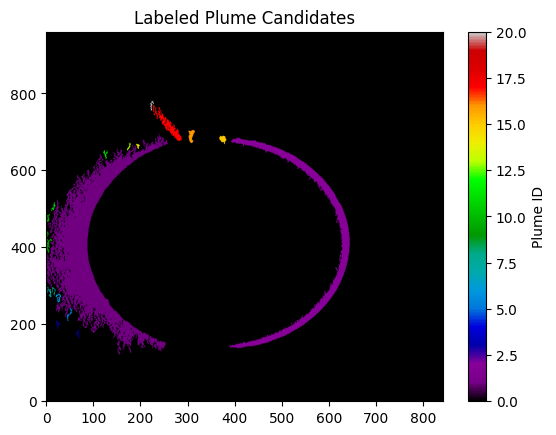

In [169]:
from skimage.morphology import remove_small_objects
from skimage.measure import label

plume_mask = mask.astype(bool)
cleaned_mask = remove_small_objects(plume_mask, min_size=50)
labeled = label(cleaned_mask)

plt.imshow(labeled, cmap='nipy_spectral', origin='lower', aspect='auto')
plt.title("Labeled Plume Candidates")
plt.colorbar(label='Plume ID')
plt.show()

In [30]:
folder = '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/FitsNullPNG'
#output_folder = '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/Yolk'
for file in os.listdir(folder):
    try:
        if file == '.DS_Store' or file == '.ipynb_checkpoints':
            continue
        SOLAR_ECLIPSE_IMAGE = f'{folder}/{file}'
        im_rgba = np.flipud(matplotlib.image.imread(SOLAR_ECLIPSE_IMAGE))
        im_rgb = im_rgba[:, :, :3]
        im = rgb2gray(im_rgb)
        plt.imshow(im, origin="lower", cmap="gray")
        #plt.show()

        print(f"Image shape: {folder}/{file}")
        blur_im = ndimage.gaussian_filter(im, 0.01)
        mask = blur_im > blur_im.mean() * 4.3
        plt.imshow(mask)
        plt.show()

        
        label_im, nb_labels = ndimage.label(mask)
        slice_y, slice_x = ndimage.find_objects(label_im == 1)[0]
        
        roi = blur_im[slice_y, slice_x]
        sx = ndimage.sobel(roi, axis=1, mode="constant")
        sy = ndimage.sobel(roi, axis=0, mode="constant")
        sob = np.hypot(sx, sy)
        #hough_radii = np.arange(np.floor(np.mean(sob.shape) / 3.6), np.ceil(np.mean(sob.shape) / 1.5), 1.5)
        r_start = float(np.floor(np.mean(sob.shape) / 3.6))
        r_end = float(np.ceil(np.mean(sob.shape) / 1.5))
        hough_radii = np.arange(r_start, r_end, 1.5)
        hough_res = hough_circle(sob > (sob.mean() * 1.9), hough_radii)
        
        # Select the most prominent circle
        accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)
        
        fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 6))
        ax[0].imshow(im[slice_y, slice_x])
        ax[0].set_title("Original")
        ax[1].imshow(sob > (sob.mean() * 5))
        ax[1].set_title("Sobel")
        circ = Circle(
            [cx, cy], radius=radii, facecolor="none", edgecolor="red", linewidth=2, linestyle="dashed", label="Hough fit"
        )
       


        ax[2].imshow(im[slice_y, slice_x])
        
        ax[2].add_patch(circ)
        ax[2].set_title("Original with fit")
        plt.legend()
        plt.show()
    except IOError as e:
        print(f"IOError with file {file}: {e}")
    except IndexError:
      print("Error: Index is out of range.")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/FitsNullPNG'

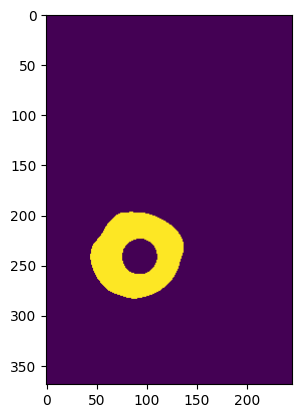

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/Yolk/mask_mask_2024-04-08_15-13-55__29c_0.png'

In [14]:
#manually changed 

#SOLAR_ECLIPSE_IMAGE = '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/FitsNullPNG/2024-04-08_15-12-19__26c_1.png'
folder = '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/FitsNullPNG'
output_folder = '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/Yolk'

#SOLAR_ECLIPSE_IMAGE = '/Users/jesuslongares/Desktop/EdEon/Projects/Cal&HDR/FitsNullPNG/2024-04-08_15-12-17__26c_1.png'
blur_im = ndimage.gaussian_filter(im, 4)
mask = blur_im > blur_im.mean() * 3.5
plt.imshow(mask)
plt.show()

im_rgba = np.flipud(matplotlib.image.imread(SOLAR_ECLIPSE_IMAGE))
im_rgb = im_rgba[:, :, :3]
im = rgb2gray(im_rgb)
#change the location of file
filename_only = os.path.basename(SOLAR_ECLIPSE_IMAGE)
output_path = os.path.join(output_folder, f'mask_{filename_only}')
plt.imsave(output_path, mask, cmap='gray')

In [1]:
import cv2
import numpy as np

import cv2
import numpy as np

# Read the images
im1_path = '/Users/jesuslongares/Desktop/FatFile/R_5Ys7VVhYIjOGiZ3/FitsNullPNG/2024-04-08_15-12-19__26c_1.png'
im2_path = '/Users/jesuslongares/Desktop/FatFile/R_5Ys7VVhYIjOGiZ3/FitsNullPNG/2024-04-08_15-12-17__26c_1.png'

im1 = cv2.imread(im1_path)
im2 = cv2.imread(im2_path)

# Check if images loaded correctly
if im1 is None:
    print(f"Failed to load image at: {im1_path}")
    exit()

if im2 is None:
    print(f"Failed to load image at: {im2_path}")
    exit()

# Proceed with alignment...

# Convert images to grayscale
im1_gray = cv2.cvtColor(im1,cv2.COLOR_BGR2GRAY)
im2_gray = cv2.cvtColor(im2,cv2.COLOR_BGR2GRAY)
 
# Find size of image1
sz = im1.shape
 
# Define the motion model
warp_mode = cv2.MOTION_TRANSLATION
 
# Define 2x3 or 3x3 matrices and initialize the matrix to identity
if warp_mode == cv2.MOTION_HOMOGRAPHY :
    warp_matrix = np.eye(3, 3, dtype=np.float32)
else :
    warp_matrix = np.eye(2, 3, dtype=np.float32)
 
# Specify the number of iterations.
number_of_iterations = 5000;
 
# Specify the threshold of the increment
# in the correlation coefficient between two iterations
termination_eps = 1e-10;
 
# Define termination criteria
criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, number_of_iterations,  termination_eps)
 
# Run the ECC algorithm. The results are stored in warp_matrix.
(cc, warp_matrix) = cv2.findTransformECC (im1_gray,im2_gray,warp_matrix, warp_mode, criteria)
 
if warp_mode == cv2.MOTION_HOMOGRAPHY :
# Use warpPerspective for Homography
    im2_aligned = cv2.warpPerspective (im2, warp_matrix, (sz[1],sz[0]), flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
else :
# Use warpAffine for Translation, Euclidean and Affine
    im2_aligned = cv2.warpAffine(im2, warp_matrix, (sz[1],sz[0]), flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP);
 
# Show final results
cv2.imshow("Image 1", im1)
cv2.imshow("Image 2", im2)
cv2.imshow("Aligned Image 2", im2_aligned)
